In [64]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.table import Table
from collections import Counter
from src.plt_params import set_rc_params

catalog_dir = "/home/alab_student/Tim/Projects/MeV_Blazars/Data/"
outdir = '/home/alab_student/Tim/Projects/MeV_Blazars/Outputs'

In [65]:
set_rc_params(fontsize=20)

In [66]:
def mask_catalog_by_class(catalog, class_column):
    fsrq_mask = [x in ['FSRQ','fsrq'] for x in catalog[class_column].tolist()]
    bll_mask = [x in ['BLL','bll'] for x in catalog[class_column].tolist()]
    bcu_mask = [x in ['BCU','bcu'] for x in catalog[class_column].tolist()]

    fsrq_masked_catalog = catalog[fsrq_mask]
    bll_masked_catalog = catalog[bll_mask]
    bcu_masked_catalog = catalog[bcu_mask]

    return fsrq_masked_catalog, bll_masked_catalog, bcu_masked_catalog

def weighted_mean_fn(values, errors):
    values = np.array(values)
    errors = np.array(errors)

    weights = 1.0 / errors**2
    weighted_mean = np.sum(values * weights) / np.sum(weights)
    
    weighted_mean_err = np.sqrt(1.0 / np.sum(weights))
    
    return weighted_mean, weighted_mean_err

def weighted_mean_asymmetric_simple(values, err_lower, err_upper):

    values = np.asarray(values, dtype=float)
    err_lower = np.asarray(err_lower, dtype=float)
    err_upper = np.asarray(err_upper, dtype=float)

    sym_err = (err_lower + err_upper) / 2.0
    weights = 1.0 / sym_err**2

    weighted_mean = np.sum(values * weights) / np.sum(weights)
    weighted_mean_err = np.sqrt(1.0 / np.sum(weights))

    return weighted_mean, weighted_mean_err

In [67]:
MeV_Blazar_Catalog_SED_Fits = Table.read(catalog_dir + "MeV_Blazar_Catalog_v2_SED_Fits.fits")

FSRQ, BLL, BCU = mask_catalog_by_class(MeV_Blazar_Catalog_SED_Fits, 'Fermi_Type')
MeV_Blazars = [FSRQ, BLL, BCU]

colors=['blue','red','purple']
labels=['FSRQ','BLL','BCU']

In [68]:
# Swift, Fermi, and synchrotron peak classification distributions

print(Counter([x.upper() for x in MeV_Blazar_Catalog_SED_Fits['Fermi_Type'].tolist()]))
print(Counter(MeV_Blazar_Catalog_SED_Fits['Swift_Type'].tolist()))
print(Counter(MeV_Blazar_Catalog_SED_Fits['SED_Class'].tolist()))

Counter({'FSRQ': 61, 'BLL': 43, 'BCU': 11})
Counter({'BZQ': 44, 'Beamed AGN': 32, 'BZB': 22, 'FSRQ': 10, 'BZG': 6, 'BZQ/Lense': 1})
Counter({'LSP': 69, 'HSP': 38, 'None': 6, 'ISP': 2})


In [69]:
print(Counter(list(zip([x.upper() for x in MeV_Blazar_Catalog_SED_Fits['Fermi_Type'].tolist()], MeV_Blazar_Catalog_SED_Fits['SED_Class'].tolist()))))

Counter({('FSRQ', 'LSP'): 56, ('BLL', 'HSP'): 34, ('BLL', 'LSP'): 7, ('BCU', 'LSP'): 6, ('FSRQ', 'None'): 5, ('BCU', 'HSP'): 4, ('BLL', 'ISP'): 2, ('BCU', 'None'): 1})


57
34
3


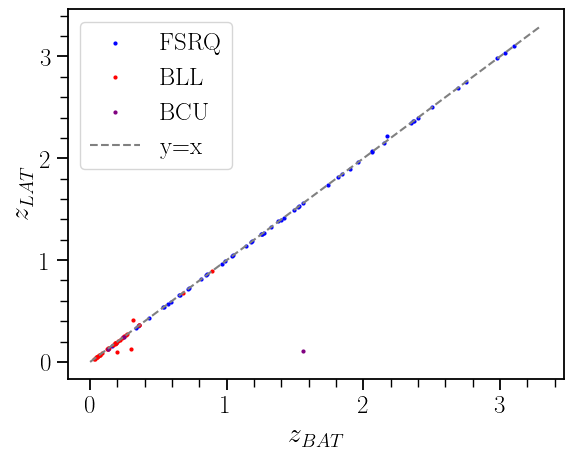

In [70]:
# Compare Swift and Fermi Redshifts for matching validation.

for i in range(len(MeV_Blazars)):
    Swift_Redshift = MeV_Blazars[i]['Swift_Redshift'].tolist()
    Fermi_Redshift = MeV_Blazars[i]['Fermi_Redshift'].tolist()
    
    Swift_Redshift_Masked = [float(Swift_Redshift[x]) for x in range(len(Swift_Redshift)) if Swift_Redshift[x] != 'None' and Fermi_Redshift[x] != 'None']
    Fermi_Redshift_Masked = [float(Fermi_Redshift[x]) for x in range(len(Swift_Redshift)) if Swift_Redshift[x] != 'None' and Fermi_Redshift[x] != 'None']
    print(len(Swift_Redshift_Masked))
    plt.scatter(Swift_Redshift_Masked, Fermi_Redshift_Masked, s=4,label=labels[i],color=colors[i])
    plt.xlabel(r'$z_{BAT}$')
    plt.ylabel(r'$z_{LAT}$')
    
plt.plot(np.linspace(0,3.3,100),np.linspace(0,3.3,100),linestyle='--',label='y=x',color='grey')
plt.legend(loc='upper left')

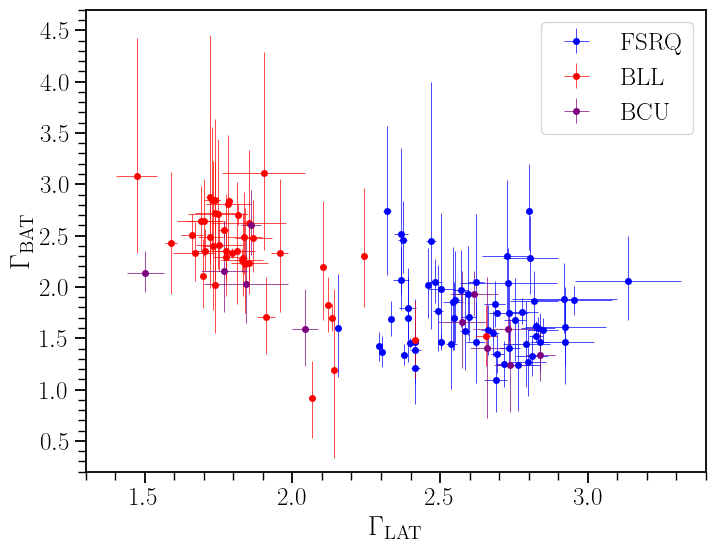

In [71]:
# Distribution of hard X-ray and GeV gamma-ray indexes (informs fitting).

plt.figure(figsize=(8,6))

for i in range(len(MeV_Blazars)):
    Name = MeV_Blazars[i]['Fermi_Counterpart_Name']
    BAT_index = MeV_Blazars[i]['Swift_Photon_Index'].tolist()
    BAT_index_err = MeV_Blazars[i]['Swift_Photon_Index_Err'].tolist()
    
    BAT_index_errors = [[],[]]
    
    for x in range(len(BAT_index_err)):
        err_lo = BAT_index[x] - BAT_index_err[x][0]
        err_hi = BAT_index_err[x][1] - BAT_index[x] 
        BAT_index_errors[0].append(err_lo)
        BAT_index_errors[1].append(err_hi)
        
    Fermi_index = MeV_Blazars[i]['Fermi_Photon_Index'].tolist()
    Fermi_index_err = [0 if x == 'None' else float(x) for x in MeV_Blazars[i]['Fermi_Photon_Index_Err'].tolist()]
    
    plt.errorbar(Fermi_index, BAT_index, yerr=BAT_index_errors, xerr=Fermi_index_err, fmt='o',markersize=4,elinewidth=0.5,color=colors[i],label=labels[i])
    plt.xlabel(r'$\Gamma_{\mathrm{LAT}}$')
    plt.ylabel(r'$\Gamma_{\mathrm{BAT}}$')

plt.xlim(1.3,3.4)
plt.ylim(0.2,4.7)
plt.legend(loc='upper right')
plt.tick_params(axis='both')

plt.savefig(outdir + '/LAT_BAT_index_comparison.pdf', dpi=300,bbox_inches='tight')

In [ ]:
def type_mask(opt_class, SED_class):
    if SED_class == None:
        mask = [x.upper() == opt_class for x in MeV_Blazar_Catalog_SED_Fits['Fermi_Type'].tolist()]
        masked_catalog = MeV_Blazar_Catalog_SED_Fits[mask]
    else:
        mask = [x.upper() == opt_class and y == SED_class for x,y in list(zip(MeV_Blazar_Catalog_SED_Fits['Fermi_Type'].tolist(), MeV_Blazar_Catalog_SED_Fits['SED_Class'].tolist()))]
        masked_catalog = MeV_Blazar_Catalog_SED_Fits[mask]
    
    photon_index = [float(x) for x in masked_catalog['Fermi_Photon_Index'].tolist()]
    photon_index_err = [float(x) if x != 'None' else 0.0001 for x in masked_catalog['Fermi_Photon_Index_Err'].tolist()]
    
    bat_index = masked_catalog['Swift_Photon_Index'].tolist()
    bat_inder_err = [[x - y[0] for x,y in list(zip(masked_catalog['Swift_Photon_Index'].tolist(), masked_catalog['Swift_Photon_Index_Err'].tolist()))], [y[1]-x for x,y in list(zip(masked_catalog['Swift_Photon_Index'].tolist(), masked_catalog['Swift_Photon_Index_Err'].tolist()))]]
    
    weighted_mean, weighted_mean_err = weighted_mean_fn(photon_index, photon_index_err)
    weighted_mean_bat, weighted_mean_err_bat = weighted_mean_asymmetric_simple(bat_index, bat_inder_err[0], bat_inder_err[1])
    
    print(f"{opt_class}, {SED_class}: (Fermi) Gamma_mean = {weighted_mean:.3f} ± {weighted_mean_err:.3f}, (Swift) Gamma_mean = {weighted_mean_bat:.3f} ± {weighted_mean_err_bat:.3f}")
    
print(type_mask('FSRQ', None))
print(type_mask('FSRQ', 'LSP'))
print(type_mask('FSRQ', 'None'))
print(type_mask('BLL', 'HSP'))
print(type_mask('BLL', 'LSP'))
print(type_mask('BCU', 'LSP'))
print(type_mask('BCU', 'HSP'))

FSRQ, None: (Fermi) Gamma_mean = 2.798 ± 0.000, (Swift) Gamma_mean = 1.683 ± 0.012
None
FSRQ, LSP: (Fermi) Gamma_mean = 2.395 ± 0.002, (Swift) Gamma_mean = 1.681 ± 0.012
None
FSRQ, None: (Fermi) Gamma_mean = 2.800 ± 0.000, (Swift) Gamma_mean = 2.177 ± 0.189
None
BLL, HSP: (Fermi) Gamma_mean = 1.768 ± 0.003, (Swift) Gamma_mean = 2.611 ± 0.024
None
BLL, LSP: (Fermi) Gamma_mean = 2.152 ± 0.003, (Swift) Gamma_mean = 1.705 ± 0.101
None
BCU, LSP: (Fermi) Gamma_mean = 2.542 ± 0.023, (Swift) Gamma_mean = 1.616 ± 0.135
None
BCU, HSP: (Fermi) Gamma_mean = 1.900 ± 0.029, (Swift) Gamma_mean = 1.892 ± 0.139
None


In [77]:
Swift_Flux = MeV_Blazar_Catalog_SED_Fits['Swift_Flux'].tolist()
Fermi_Flux = MeV_Blazar_Catalog_SED_Fits['Fermi_Flux'].tolist()

print(f"Minimum matched BAT Flux = {min(Swift_Flux)} erg/cm^2/s, Maximum matched BAT Flux = {max(Swift_Flux):.2e} erg/cm^2/s")
print(f"Minimum matched LAT Flux = {min(Fermi_Flux):.2e} erg/cm^2/s, Maximum matched LAT Flux = {max(Fermi_Flux):.2e} erg/cm^2/s")

Minimum matched BAT Flux = 4.11e-12 erg/cm^2/s, Maximum matched BAT Flux = 3.78e-10 erg/cm^2/s
Minimum matched LAT Flux = 6.83e-13 erg/cm^2/s, Maximum matched LAT Flux = 7.37e-10 erg/cm^2/s


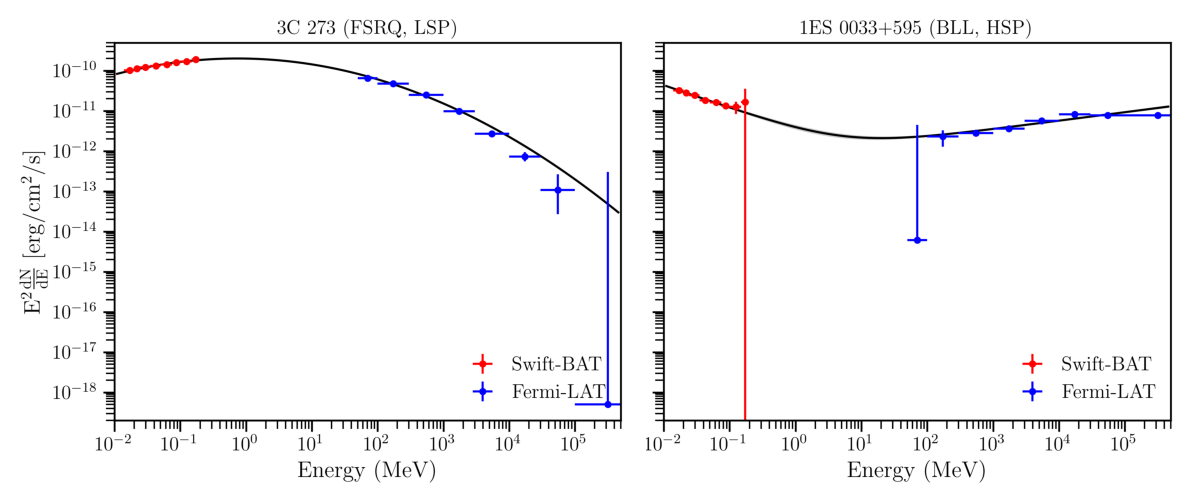

In [74]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
import numpy as np
from PIL import Image

def load_and_crop(path, crop_left=0, crop_right=0, crop_top=0, crop_bottom=0):
    img = Image.open(path)
    width, height = img.size
    box = (crop_left, crop_top, width - crop_right, height - crop_bottom)
    return np.array(img.crop(box))

img1 = load_and_crop('/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/Blazar_Fitter_out/Matched_Blazar_Fits_LP/fsrq/png_plots/3C 273.png', crop_left=0)
img2 = load_and_crop('/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/Blazar_Fitter_out/Matched_Blazar_Fits_SBPL/bll/png_plots/1ES 0033+595.png', crop_left=255)

h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

# Use the taller image's height as reference; scale widths accordingly
ref_height = max(h1, h2)
rel_width1 = w1 / h1 * ref_height
rel_width2 = w2 / h2 * ref_height

fig = plt.figure(figsize=(12, 6))
gs = GridSpec(1, 2, width_ratios=[rel_width1, rel_width2], figure=fig)

ax1 = fig.add_subplot(gs[0])
ax1.imshow(img1, extent=[0, w1, 0, h1])
ax1.set_aspect('equal')
ax1.axis('off')

ax2 = fig.add_subplot(gs[1])
ax2.imshow(img2, extent=[0, w2, 0, h2])
ax2.set_aspect('equal')
ax2.axis('off')

plt.tight_layout()
plt.savefig(outdir + '/Example_SEDS.png', dpi=300, bbox_inches='tight')
plt.savefig(outdir + '/Example_SEDS.pdf', dpi=300, bbox_inches='tight')